## Setup

In [ ]:

%pip install numpy matplotlib pandas

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Dataset

In [21]:
df = pd.read_csv("Heart_Disease_prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [22]:
print("Dataset shape:", df.shape)
print(df.info())

Dataset shape: (270, 14)
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1

In [23]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


#### Binarize target column

In [24]:
df['Heart Disease'] = df['Heart Disease'].apply(lambda x: 1 if x == "Presence" else 0)

df['Heart Disease'].value_counts()

Heart Disease
0    150
1    120
Name: count, dtype: int64

#### Outliers

In [17]:
numerical_cols = [
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression'
]

for col in numerical_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)



#### Plot Class Distribution

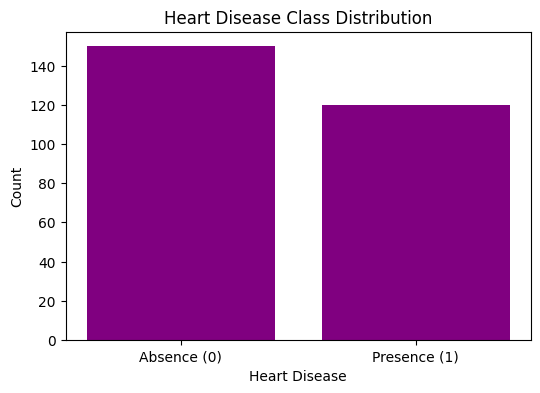

In [31]:
plt.figure(figsize=(6,4))
counts = df['Heart Disease'].value_counts()

plt.bar(['Absence (0)', 'Presence (1)'], counts.sort_index(), color = "Purple")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Heart Disease Class Distribution")
plt.show()


#### Stratified 70/30 Train & Feature Selection

In [32]:
features = [
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

X = df[features]
y = df['Heart Disease']


In [33]:
data = df[features + ['Heart Disease']]

class_0 = data[data['Heart Disease'] == 0]
class_1 = data[data['Heart Disease'] == 1]

train_0 = class_0.sample(frac=0.7, random_state=42)
train_1 = class_1.sample(frac=0.7, random_state=42)

test_0 = class_0.drop(train_0.index)
test_1 = class_1.drop(train_1.index)

train_df = pd.concat([train_0, train_1]).sample(frac=1, random_state=42)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=42)

X_train = train_df[features]
y_train = train_df['Heart Disease']

X_test = test_df[features]
y_test = test_df['Heart Disease']


#### Normalize Features

In [ ]:
X_train_norm = (X_train - X_train.mean()) / X_train.std()
X_test_norm = (X_test - X_train.mean()) / X_train.std()

#### Dataset Overview

The Heart Disease dataset was downloaded from Kaggle.
It contains 270 patient records with clinical features related to heart health.

- Samples: 270
- Target variable: Heart Disease
- Class distribution: ~66.66% without diesease, ~44.44% with disease

##### Exploratory Data Analysis (EDA)

- Numerical features such as Age, BP (Blood pressure), Cholesterol, Max HR, 
- The dataset contains no major missing values.
- Class distribution shows a slight imbalance but is acceptable for modeling.
- Higher cholesterol and ST depression values tend to correlate with disease presence.

##### Data Preprocessing

- Target column was binarized:
  - `1` = presence of heart disease
  - `0` = absence of heart disease
- Selected features:
  - Age
  - Cholesterol
  - Resting Blood Pressure
  - Maximum Heart Rate
  - ST Depression
  - Number of Major Vessels
- Data was split into training and testing sets using a 70/30 stratified split.
- Numerical features were normalized using standard scaling.

##### Summary

The dataset is clean, well-balanced, and suitable for binary classification tasks.
Preprocessing ensured normalized feature scales and preserved class distribution for model training.
